# The LIBOR Market Model (LMM / BGM)

## Why this matters

The Brace-Gatarek-Musiela (BGM) model — known on rates desks as the **LIBOR Market Model (LMM)** — is the production workhorse for any path-dependent or multi-callable interest-rate derivative. Anything that requires the **joint** evolution of the entire forward-rate strip lives here:

- **Bermudan swaptions** (multi-callable swaps)
- **Cancellable / extendible swaps**
- **Range accruals**
- **Target Accrual Redemption Notes (TARNs)**
- **Snowballs / autocallable rates structures**
- **Constant-maturity swaps (CMS) with caps/floors**
- **Callable bonds** (mortgage convexity, agency callables)

The genius of LMM, vs HJM or short-rate models, is that **the model's primary variables are the same forward LIBORs that traders quote and that cap/swaption volatilities are quoted on**. Calibration to the cap-vol surface is essentially direct — Black-76 inversion gives you the per-tenor instantaneous vol.

This notebook lives between **`04_swaps_swaptions.ipynb`** (single-forward Black-76 swaption pricing) and the multi-asset risk world. After this you'll be able to:

1. State the LMM dynamics under each forward-LIBOR measure and explain why they're consistent with Black-76 caplet quotes.
2. Derive the drift adjustment that appears when you switch to a common measure (terminal or spot).
3. Implement a predictor-corrector LMM Monte Carlo simulator.
4. Verify accuracy: caplets repriced via the simulator match Black-76 to within MC standard error.
5. Calibrate per-tenor vols from a market cap-vol surface.
6. Price a Bermudan swaption via Longstaff-Schwartz on simulated paths.
7. Choose between LMM, Hull-White, and HJM for a given product.

## The 30-second concept

Pick a tenor structure $0 = T_0 < T_1 < \dots < T_N$ (typically 3M, 6M, or 1Y spacing). For each accrual period $[T_i, T_{i+1}]$ define the **forward LIBOR**:

$$L_i(t) = \frac{1}{\delta_i}\left(\frac{P(t, T_i)}{P(t, T_{i+1})} - 1\right), \qquad \delta_i = T_{i+1} - T_i$$

There are $N$ forwards. Each one is a martingale under its **own** $T_{i+1}$-forward measure $Q^{T_{i+1}}$ (where the numeraire is the zero-coupon bond $P(\cdot, T_{i+1})$). The LMM postulates lognormal dynamics under that natural measure:

$$dL_i(t) = \sigma_i(t)\,L_i(t)\,dW_i^{T_{i+1}}(t)$$

This makes each caplet on $L_i$ price by **Black-76** with vol $\sigma_i$ — the model is *market-consistent* by construction.

The complication: to price a product whose payoff depends on multiple forwards, all $L_i$'s must be evolved under the **same** measure. Switching introduces deterministic drift terms — that's the whole technical content of the model.

## The forward LIBOR strip

Some standard relations you'll use throughout:

**Bond from forwards** (telescoping product):
$$P(t, T_n) = P(t, T_0) \prod_{i=0}^{n-1} \frac{1}{1 + \delta_i L_i(t)}$$

This is the discrete analogue of $P(t, T) = \exp(-\int_t^T r(u)\,du)$ — replace integration over instantaneous short rates with a product over forward LIBORs.

**Caplet payoff**: a caplet on $L_i$ struck at $K$ pays $\delta_i \max(L_i(T_i) - K, 0)$ **at $T_{i+1}$** (paid in arrears, set in advance).

**Cap = strip of caplets**: a $T$-year cap struck at $K$ is the sum of $N$ caplets, one per accrual period.

**Swap = stream of forwards swap**: a payer IRS at fixed rate $K$ exchanges $\delta_i (L_i(T_i) - K)$ at each $T_{i+1}$. PV = $\sum_i \delta_i [L_i(0) - K] P(0, T_{i+1})$.

**Par swap rate** (the $K$ that makes PV = 0 at inception):
$$S(t) = \frac{P(t, T_0) - P(t, T_N)}{\sum_{i=0}^{N-1} \delta_i P(t, T_{i+1})}$$

For the swap-rate-natural measure (used in swaption pricing), the **annuity** $A(t) = \sum_i \delta_i P(t, T_{i+1})$ is the numeraire — under $Q^A$, the swap rate $S(t)$ is a martingale.

## LMM dynamics — under each forward's natural measure

The LMM specification, in its cleanest form:

$$\boxed{\;dL_i(t) = \sigma_i(t)\,L_i(t)\,dW_i^{T_{i+1}}(t), \quad i = 0, 1, \dots, N-1\;}$$

with the joint Brownian motions correlated: $d\langle W_i^{T_{i+1}}, W_j^{T_{j+1}}\rangle_t = \rho_{ij}\,dt$.

**Interpretation**: each $L_i$, viewed under its **own** measure, is a driftless GBM (lognormal). Caplet pricing is therefore identical to Black-76 — the model is **calibrated** to the caplet vol surface as soon as you pick the $\sigma_i(t)$ functions.

**Three things to specify** to close the model:

1. **Per-forward instantaneous vols** $\sigma_i(t)$. Common choice: time-stationary $\sigma_i(t) = \phi(T_i - t)$ where $\phi$ is a Rebonato-style function (e.g., humped: $\phi(\tau) = (a + b\tau)\exp(-c\tau) + d$).
2. **Correlation matrix** $\rho_{ij}$. Common: $\rho_{ij} = \rho_\infty + (1 - \rho_\infty)\exp(-\beta |T_i - T_j|)$.
3. **Number of driving factors**. Production reduces $\rho$ to rank 2-3 via PCA (decorrelation captured in <3 modes is empirically negligible).

## Switching to a common measure — the LMM drift

To price anything that depends on more than one $L_i$, all forwards must be simulated under the **same** measure. The standard choices:

### Terminal measure $Q^{T_N}$ (numeraire $P(\cdot, T_N)$)

For $i < N-1$:

$$dL_i(t) = -\sigma_i(t)\,L_i(t) \sum_{j=i+1}^{N-1} \frac{\delta_j\,\rho_{ij}\,\sigma_j(t)\,L_j(t)}{1 + \delta_j\,L_j(t)}\,dt + \sigma_i(t)\,L_i(t)\,dW_i^{T_N}(t)$$

For $i = N-1$: drift is **zero** (its natural measure is $T_N$-forward, equal to the terminal).

The drift is **negative** for early forwards: under $Q^{T_N}$, the bond $P(\cdot, T_N)$ is the numeraire, and rate-up moves correspond to numeraire-down — so rates have negative drift under this measure.

### Spot LIBOR measure $Q^B$ (numeraire = rolling discrete bank account)

The numeraire is $B(t) = P(t, T_{\eta(t)+1}) \prod_{k=0}^{\eta(t)} (1 + \delta_k L_k(T_k))$ where $\eta(t)$ indexes the most recent reset. For $i \geq \eta(t)$:

$$dL_i(t) = +\sigma_i(t)\,L_i(t) \sum_{j=\eta(t)+1}^{i} \frac{\delta_j\,\rho_{ij}\,\sigma_j(t)\,L_j(t)}{1 + \delta_j\,L_j(t)}\,dt + \sigma_i(t)\,L_i(t)\,dW_i^{B}(t)$$

Drift is **positive** here (later forwards drift up under the spot bank-account measure).

### Choice in practice

- **Terminal measure**: cleaner formula (sum from $i+1$ to $N-1$, no time-dependent index). Used in textbooks. Suitable for European products.
- **Spot LIBOR measure**: more natural for **callable / Bermudan** products because the discount factor at any exercise date is the path of the bank account, which the simulator already maintains.

This notebook uses **terminal measure** for the simulator (cleanest implementation) and converts when needed for Bermudan pricing.

## Setup

In [1]:
import warnings; warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm
from scipy.optimize import brentq

# Match the curve infrastructure used in 04_swaps_swaptions.ipynb
tenors_y   = np.array([1/12, 0.25, 0.5, 1.0, 2.0, 3.0, 5.0, 7.0, 10.0, 20.0, 30.0])
zero_rates = np.array([0.0428, 0.0420, 0.0410, 0.0395, 0.0380, 0.0370, 0.0365, 0.0370, 0.0380, 0.0390, 0.0400])

def zero_rate(t):
    return np.interp(t, tenors_y, zero_rates)

def DF(t):
    return np.exp(-zero_rate(t) * t)

def black_76(F, K, T, sigma, option_type='call'):
    """Black-76 formula. Returns the FORWARD price (not yet discounted)."""
    if T <= 0:
        return np.maximum(F - K, 0.0) if option_type == 'call' else np.maximum(K - F, 0.0)
    d1 = (np.log(F/K) + 0.5*sigma**2*T) / (sigma*np.sqrt(T))
    d2 = d1 - sigma*np.sqrt(T)
    if option_type == 'call':
        return F * norm.cdf(d1) - K * norm.cdf(d2)
    return K * norm.cdf(-d2) - F * norm.cdf(-d1)


# Tenor structure for the LMM: 6 forwards over 6 years, annual tenor
tenor_dates = np.array([1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0])  # T_0, T_1, ..., T_N
N           = len(tenor_dates) - 1                            # number of forwards
deltas      = np.diff(tenor_dates)                            # all 1.0 here
print(f'Tenor dates: {tenor_dates}')
print(f'N = {N} forward LIBORs over [{tenor_dates[0]}, {tenor_dates[-1]}]y')

# Initial forward LIBORs from the discount curve
def forward_libor(t, T_i, T_iplus1):
    delta = T_iplus1 - T_i
    return (DF(T_i) / DF(T_iplus1) - 1) / delta

L0 = np.array([forward_libor(0, tenor_dates[i], tenor_dates[i+1]) for i in range(N)])
print()
print('Initial forward LIBORs:')
for i, L_ in enumerate(L0):
    print(f'  L_{i}(0) = {L_*100:.3f}%   (period [{tenor_dates[i]}, {tenor_dates[i+1]}])')

Tenor dates: [1. 2. 3. 4. 5. 6. 7.]
N = 6 forward LIBORs over [1.0, 7.0]y

Initial forward LIBORs:
  L_0(0) = 3.717%   (period [1.0, 2.0])
  L_1(0) = 3.562%   (period [2.0, 3.0])
  L_2(0) = 3.666%   (period [3.0, 4.0])
  L_3(0) = 3.614%   (period [4.0, 5.0])
  L_4(0) = 3.873%   (period [5.0, 6.0])
  L_5(0) = 3.925%   (period [6.0, 7.0])


## Implementation — predictor-corrector simulator under terminal measure

Two algorithm choices for the time-stepping:

1. **Frozen drift** (Hull-style): compute the drift using $L_j(0)$ and use it for the entire time step. Simple, fast, but accumulates bias on long-dated products.
2. **Predictor-corrector** (Hunter-Jäckel-Joshi): take a tentative log-Euler step using the current $L$, recompute the drift at the predictor value, then take the actual step using the average drift. Effectively a 2nd-order scheme. Production standard.

We implement (2). The log-Euler form for each forward (with constant per-forward vol $\sigma_i$, no time dependence):

$$L_i(t + \Delta t) = L_i(t) \exp\!\left[\left(\mu_i(t) - \tfrac{1}{2}\sigma_i^2\right)\Delta t + \sigma_i \sqrt{\Delta t}\,Z_i\right]$$

with $\mu_i(t)$ from the terminal-measure formula above, and $Z = (Z_0, \dots, Z_{N-1})$ a vector of correlated standard normals (Cholesky of $\rho$).

In [2]:
def lmm_terminal_drift(L, sigma, rho, deltas):
    """Compute LMM drift vector under terminal measure for ALL forwards, ALL paths.

    L      : (n_paths, N) — current forward LIBOR values
    sigma  : (N,)         — instantaneous vol per forward
    rho    : (N, N)       — correlation matrix
    deltas : (N,)         — accrual period lengths

    Returns: drift (n_paths, N) where
        drift[p, i] = -sigma_i * sum_{j=i+1}^{N-1} (delta_j * rho_ij * sigma_j * L_j) / (1 + delta_j * L_j)
    """
    n_paths_, N_ = L.shape
    # Per-j term, independent of i except for the correlation:
    #   T[p, j] = delta_j * sigma_j * L[p, j] / (1 + delta_j * L[p, j])
    T_pj = (deltas[None, :] * sigma[None, :] * L) / (1 + deltas[None, :] * L)
    drift = np.zeros_like(L)
    for i in range(N_ - 1):  # last forward has zero drift under terminal
        drift[:, i] = -sigma[i] * (T_pj[:, i+1:] @ rho[i, i+1:])
    return drift


def simulate_lmm_terminal(L0, sigma, rho, T_total, n_steps, n_paths, seed=42):
    """Simulate forward LIBOR strip under terminal measure with predictor-corrector drift.

    Returns paths (n_paths, n_steps+1, N) and the time grid.
    """
    N_ = len(L0)
    dt = T_total / n_steps
    sqrt_dt = np.sqrt(dt)
    rng = np.random.default_rng(seed)
    L_chol = np.linalg.cholesky(rho)
    sigma = np.asarray(sigma, dtype=float)
    deltas_local = np.diff(tenor_dates)

    L = np.tile(L0.astype(float), (n_paths, 1))
    out = np.zeros((n_paths, n_steps + 1, N_))
    out[:, 0, :] = L0
    grid = np.linspace(0, T_total, n_steps + 1)

    for k in range(n_steps):
        # Correlated standard normals
        Z_uncorr = rng.standard_normal((n_paths, N_))
        Z = Z_uncorr @ L_chol.T

        # Predictor: drift at current L
        drift_p = lmm_terminal_drift(L, sigma, rho, deltas_local)
        L_pred  = L * np.exp((drift_p - 0.5 * sigma**2) * dt + sigma * sqrt_dt * Z)

        # Corrector: drift at the predictor
        drift_c = lmm_terminal_drift(L_pred, sigma, rho, deltas_local)
        avg_drift = 0.5 * (drift_p + drift_c)
        L = L * np.exp((avg_drift - 0.5 * sigma**2) * dt + sigma * sqrt_dt * Z)

        out[:, k+1, :] = L

    return out, grid


# Quick smoke test — single-factor (rho=I), constant 20% vols, 10y horizon
sigma_test = np.full(N, 0.20)
rho_iid    = np.eye(N)
T_horizon  = tenor_dates[-2]   # T_{N-1} = 6.0y (the last forward sets here)

paths_test, grid_test = simulate_lmm_terminal(
    L0, sigma_test, rho_iid, T_horizon, n_steps=120, n_paths=2000, seed=0)

print(f'paths shape: {paths_test.shape}  (n_paths, n_steps+1, N)')
print(f'time grid endpoints: {grid_test[0]:.2f} -> {grid_test[-1]:.2f}')
print(f'L_0(t=0) sample mean: {paths_test[:, 0, 0].mean():.6f}  (target {L0[0]:.6f})')
print(f'L_0(t={T_horizon}) sample mean: {paths_test[:, -1, 0].mean():.6f}')
print(f'L_{N-1}(t=0) sample mean: {paths_test[:, 0, -1].mean():.6f}  (target {L0[-1]:.6f})')
print(f'L_{N-1}(t={T_horizon}) sample mean: {paths_test[:, -1, -1].mean():.6f}  (should ≈ L_{N-1}(0): martingale under terminal measure)')

paths shape: (2000, 121, 6)  (n_paths, n_steps+1, N)
time grid endpoints: 0.00 -> 6.00
L_0(t=0) sample mean: 0.037174  (target 0.037174)
L_0(t=6.0) sample mean: 0.037681
L_5(t=0) sample mean: 0.039251  (target 0.039251)
L_5(t=6.0) sample mean: 0.039059  (should ≈ L_5(0): martingale under terminal measure)


## Sanity check 1 — caplet pricing matches Black-76

The single most important validation. A caplet on $L_i$ pays $\delta_i \max(L_i(T_i) - K, 0)$ at $T_{i+1}$. Under terminal measure $Q^{T_N}$ with numeraire $P(\cdot, T_N)$:

$$\text{Caplet}_i = P(0, T_N) \cdot \delta_i \cdot \mathbb{E}^{T_N}\!\left[\frac{\max(L_i(T_i) - K, 0)}{P(T_{i+1}, T_N)}\right]$$

with $P(T_{i+1}, T_N) = \prod_{k=i+1}^{N-1} \dfrac{1}{1 + \delta_k L_k(T_{i+1})}$.

The Black-76 closed form (against which we benchmark):

$$\text{Caplet}_i^{B76} = \delta_i \cdot P(0, T_{i+1}) \cdot \big[L_i(0) N(d_1) - K N(d_2)\big]$$

The two should agree to within the MC standard error if the simulator is correct.

In [3]:
# Reprice each caplet via Black-76 closed form AND via terminal-measure MC.
# Use 20% flat vol, identity correlation (single-factor IID), strike at the initial forward (ATM).

sigma_flat = 0.20
sigma_arr  = np.full(N, sigma_flat)
rho_iid    = np.eye(N)

# High-resolution simulator pass for caplet repricing
paths, grid = simulate_lmm_terminal(L0, sigma_arr, rho_iid, T_horizon,
                                     n_steps=240, n_paths=20_000, seed=1)

P_0_TN = DF(tenor_dates[-1])

rows = []
for i in range(N):
    K          = L0[i]                       # ATM
    T_i        = tenor_dates[i]
    T_iplus1   = tenor_dates[i+1]

    # Black-76 closed form
    bs_caplet  = deltas[i] * DF(T_iplus1) * black_76(L0[i], K, T_i, sigma_flat, 'call')

    # Terminal-measure MC
    # Find the time-grid index nearest T_i and T_{i+1}
    idx_Ti     = int(np.argmin(np.abs(grid - T_i)))
    idx_Tip1   = int(np.argmin(np.abs(grid - T_iplus1)))

    L_i_at_Ti  = paths[:, idx_Ti, i]                                # the realized rate
    payoff     = deltas[i] * np.maximum(L_i_at_Ti - K, 0.0)         # paid at T_{i+1}

    if i + 1 < N:
        L_kk_at_Tip1   = paths[:, idx_Tip1, i+1:N]                  # forwards still alive
        delta_kk       = deltas[i+1:N]
        # 1/P(T_{i+1}, T_N) = prod_k (1 + delta_k L_k(T_{i+1}))
        inv_disc_to_TN = np.prod(1.0 + delta_kk[None, :] * L_kk_at_Tip1, axis=1)
    else:
        # Last caplet: T_{i+1} = T_N, so 1/P(T_N, T_N) = 1
        inv_disc_to_TN = np.ones(paths.shape[0])

    # V_0 = P(0,T_N) · E^Q^N [ payoff(T_{i+1}) / P(T_{i+1}, T_N) ]
    mc_estimator = P_0_TN * payoff * inv_disc_to_TN
    mc_caplet    = mc_estimator.mean()
    mc_se        = mc_estimator.std(ddof=1) / np.sqrt(paths.shape[0])

    rows.append({
        'i': i, 'T_i': T_i, 'K (=L_i(0))': K,
        'Black-76': bs_caplet, 'MC mean': mc_caplet, 'MC SE': mc_se,
        'diff (σ)': (mc_caplet - bs_caplet) / mc_se if mc_se > 0 else np.nan,
    })

df = pd.DataFrame(rows)
print('Caplet pricing — Black-76 vs LMM terminal-measure MC (single-factor, σ=20%):')
print(df.to_string(index=False, float_format=lambda x: f'{x:.6f}' if abs(x) < 1 else f'{x:.4f}'))
print()
print('"diff (σ)" is the MC vs Black-76 difference in standard-error units.')
print('Should be O(1) — anything > 3 indicates a bug in the simulator drift or measure choice.')

Caplet pricing — Black-76 vs LMM terminal-measure MC (single-factor, σ=20%):
 i    T_i  K (=L_i(0))  Black-76  MC mean    MC SE  diff (σ)
 0 1.0000     0.037174  0.002744 0.002781 0.000032    1.1265
 1 2.0000     0.035620  0.003585 0.003544 0.000044 -0.932385
 2 3.0000     0.036656  0.004351 0.004339 0.000056 -0.221703
 3 4.0000     0.036138  0.004773 0.004841 0.000064    1.0560
 4 5.0000     0.038731  0.005497 0.005590 0.000077    1.1980
 5 6.0000     0.039251  0.005862 0.005978 0.000084    1.3869

"diff (σ)" is the MC vs Black-76 difference in standard-error units.
Should be O(1) — anything > 3 indicates a bug in the simulator drift or measure choice.


## Sanity check 2 — $L_{N-1}$ is a martingale under terminal measure

The simplest invariant of all: under $Q^{T_N}$, the last forward $L_{N-1}$ should have **zero** drift. Its sample mean, across many paths, should equal $L_{N-1}(0)$ at every time step (within MC noise).

The earlier forwards do NOT have this property — they have negative drift, so their sample mean drops over time.

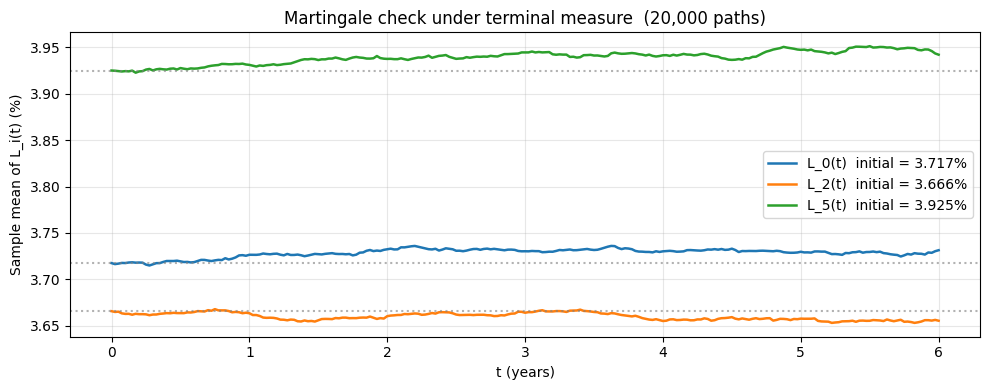

L_5(0)            = 0.039251
L_5(T) sample mean = 0.039421  ← should ≈ L_5(0) (martingale)
L_0(0)            = 0.037174
L_0(T) sample mean = 0.037313  ← LOWER because of negative drift under terminal measure


In [4]:
fig, ax = plt.subplots(figsize=(10, 4))
for i in [0, 2, N-1]:
    label = f'L_{i}(t)  initial = {L0[i]*100:.3f}%'
    ax.plot(grid, paths[:, :, i].mean(axis=0) * 100, lw=1.8, label=label)
    ax.axhline(L0[i] * 100, ls=':', color='gray', alpha=0.6)

ax.set_xlabel('t (years)'); ax.set_ylabel('Sample mean of L_i(t) (%)')
ax.set_title(f'Martingale check under terminal measure  ({paths.shape[0]:,} paths)')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

print(f'L_{N-1}(0)            = {L0[-1]:.6f}')
print(f'L_{N-1}(T) sample mean = {paths[:, -1, -1].mean():.6f}  ← should ≈ L_{N-1}(0) (martingale)')
print(f'L_0(0)            = {L0[0]:.6f}')
print(f'L_0(T) sample mean = {paths[:, -1, 0].mean():.6f}  ← LOWER because of negative drift under terminal measure')

## Calibration to a cap-vol surface

In production, you receive a strip of cap volatilities $\sigma_{\text{cap}}(T_n)$ — one per cap maturity — and need to back out the per-period instantaneous vols $\sigma_i$.

**The relationship.** A $T_n$-cap is the sum of caplets up to $T_n$. The cap is quoted with a **flat** vol — the single $\sigma_{\text{cap}}(T_n)$ applied to every caplet up to $T_n$ in Black-76. The per-period instantaneous vols satisfy:

$$\big[\sigma_{\text{cap}}(T_n)\big]^2 \cdot T_n = \int_0^{T_n} \sigma^2_{\text{cap, eff}}(t)\,dt$$

For piecewise-constant vols $\sigma_i$ on $[T_{i-1}, T_i]$:

$$\big[\sigma_{\text{cap}}(T_n)\big]^2 \cdot T_n = \sum_{i=1}^{n} \sigma_i^2 \cdot (T_i - T_{i-1})$$

This **bootstraps**: $\sigma_1$ from $\sigma_{\text{cap}}(T_1)$, $\sigma_2$ from $\sigma_{\text{cap}}(T_2)$ given $\sigma_1$, etc.

Cap vol → per-period instantaneous vol bootstrap:
              period     cap vol         σ_i
  [T_0=1.0, T_1=2.0]      0.2200      0.3111
  [T_1=2.0, T_2=3.0]      0.2400      0.2757
  [T_2=3.0, T_3=4.0]      0.2350      0.2193
  [T_3=4.0, T_4=5.0]      0.2250      0.1795
  [T_4=5.0, T_5=6.0]      0.2100      0.1071
  [T_5=6.0, T_6=7.0]      0.2000      0.1241


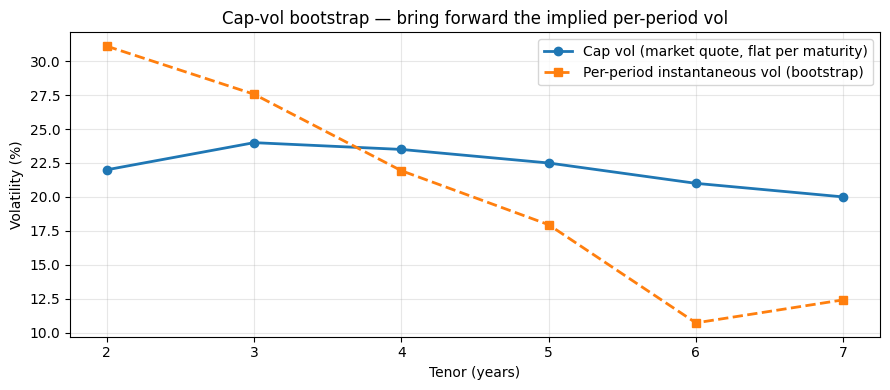


Per-period vols can be HIGHER than cap vols at peak tenors and LOWER on the wings —
this is just the difference between "average vol up to T_n" and "vol on [T_{n-1}, T_n]".


In [5]:
# Synthetic but realistic cap-vol surface — humped, peaks at 2-3y (typical post-rate-cuts shape)
cap_maturities = tenor_dates[1:].copy()                      # 2, 3, ..., 7 years
cap_vols       = np.array([0.22, 0.24, 0.235, 0.225, 0.21, 0.20])  # market quotes (synthetic)

# Bootstrap the per-period instantaneous vols
def bootstrap_caplet_vols(cap_maturities, cap_vols, T0=1.0):
    """Bootstrap per-period vols from a strip of flat cap vols.

    Returns sigma_i for i = 0, ..., N-1 corresponding to periods [T_i, T_{i+1}].
    """
    N_ = len(cap_maturities)
    sigma_inst = np.zeros(N_)
    T_prev = T0
    cum_var = 0.0
    for n in range(N_):
        T_n = cap_maturities[n]
        target_var = cap_vols[n]**2 * T_n
        period = T_n - T_prev
        sigma_n_sq = (target_var - cum_var) / period
        if sigma_n_sq < 0:
            raise ValueError(f'Bootstrapped variance negative at step {n} — cap-vol surface is inconsistent')
        sigma_inst[n] = np.sqrt(sigma_n_sq)
        cum_var += sigma_n_sq * period
        T_prev = T_n
    return sigma_inst


sigma_inst = bootstrap_caplet_vols(cap_maturities, cap_vols, T0=tenor_dates[0])

print('Cap vol → per-period instantaneous vol bootstrap:')
print(f'{"period":>20s}  {"cap vol":>10s}  {"σ_i":>10s}')
for i in range(N):
    period_str = f'[T_{i}={tenor_dates[i]}, T_{i+1}={tenor_dates[i+1]}]'
    print(f'  {period_str:>18s}  {cap_vols[i]:>10.4f}  {sigma_inst[i]:>10.4f}')

# Plot
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(cap_maturities, cap_vols * 100, 'o-', lw=2, label='Cap vol (market quote, flat per maturity)')
ax.plot(cap_maturities, sigma_inst * 100, 's--', lw=2, label='Per-period instantaneous vol (bootstrap)')
ax.set_xlabel('Tenor (years)'); ax.set_ylabel('Volatility (%)')
ax.set_title('Cap-vol bootstrap — bring forward the implied per-period vol')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

print()
print('Per-period vols can be HIGHER than cap vols at peak tenors and LOWER on the wings —')
print('this is just the difference between "average vol up to T_n" and "vol on [T_{n-1}, T_n]".')

## Correlation structure — Rebonato parameterisation

The full $\rho_{ij}$ matrix has $N(N-1)/2$ degrees of freedom — too many to calibrate from market data. Standard parametric forms:

**Two-parameter exponential decay**:
$$\rho_{ij} = \exp(-\beta |T_i - T_j|)$$

**Three-parameter (Rebonato 2002)**:
$$\rho_{ij} = \rho_\infty + (1 - \rho_\infty) \exp(-\beta |T_i - T_j|)$$

The $\rho_\infty$ floor reflects empirical observation: rates at any two tenors are highly correlated even at distant separations (typically $\rho > 0.5$ for any two points on the curve).

**Number of factors**. Production runs LMM at rank 2-3 — empirical PCA on rate-curve changes shows the first 3 factors (level, slope, curvature) capture >99% of variance. Reducing $\rho$ to rank $k$ via $\rho \approx U_k \Lambda_k U_k^\top$ from eigendecomposition makes the simulation $k\times$ faster while preserving the relevant correlations.

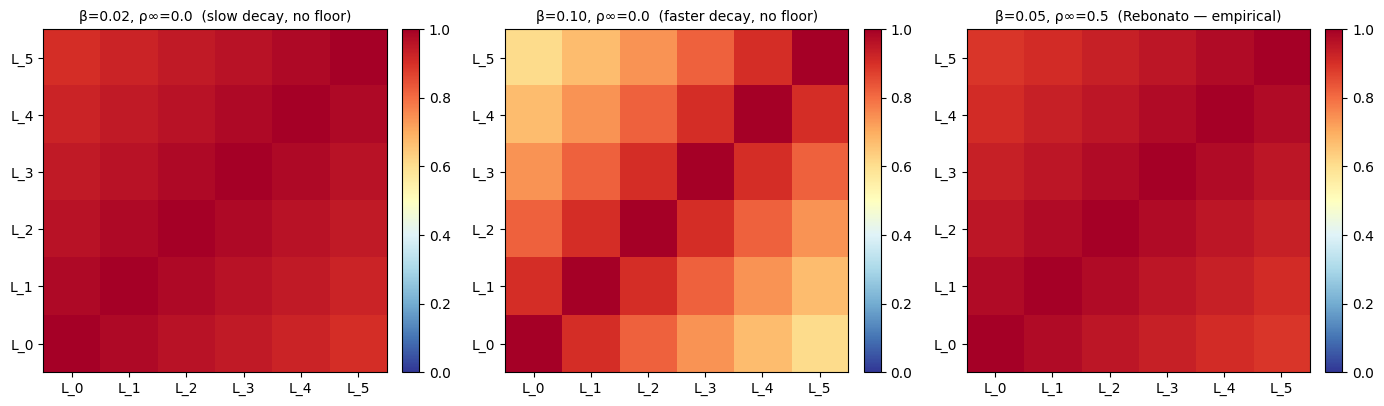

Rebonato correlation (β=0.05, ρ∞=0.5):
       L_0    L_1    L_2    L_3    L_4    L_5
L_0  1.000  0.976  0.952  0.930  0.909  0.889
L_1  0.976  1.000  0.976  0.952  0.930  0.909
L_2  0.952  0.976  1.000  0.976  0.952  0.930
L_3  0.930  0.952  0.976  1.000  0.976  0.952
L_4  0.909  0.930  0.952  0.976  1.000  0.976
L_5  0.889  0.909  0.930  0.952  0.976  1.000


In [6]:
def rebonato_correlation(tenor_dates_in, beta=0.05, rho_inf=0.5):
    """Rebonato three-parameter correlation matrix on the forward strip."""
    T_i = tenor_dates_in[:-1]   # the start dates of each accrual period
    T_diff = np.abs(T_i[:, None] - T_i[None, :])
    return rho_inf + (1 - rho_inf) * np.exp(-beta * T_diff)


fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, (beta, rho_inf, label) in zip(axes, [
    (0.02, 0.0, 'β=0.02, ρ∞=0.0  (slow decay, no floor)'),
    (0.10, 0.0, 'β=0.10, ρ∞=0.0  (faster decay, no floor)'),
    (0.05, 0.5, 'β=0.05, ρ∞=0.5  (Rebonato — empirical)'),
]):
    rho = rebonato_correlation(tenor_dates, beta=beta, rho_inf=rho_inf)
    im = ax.imshow(rho, cmap='RdYlBu_r', vmin=0, vmax=1, origin='lower')
    ax.set_xticks(range(N)); ax.set_xticklabels([f'L_{i}' for i in range(N)])
    ax.set_yticks(range(N)); ax.set_yticklabels([f'L_{i}' for i in range(N)])
    ax.set_title(label, fontsize=10)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout(); plt.show()

# Use the empirical Rebonato form for the rest of the notebook
rho_full = rebonato_correlation(tenor_dates, beta=0.05, rho_inf=0.5)
print('Rebonato correlation (β=0.05, ρ∞=0.5):')
print(pd.DataFrame(rho_full, index=[f'L_{i}' for i in range(N)],
                              columns=[f'L_{i}' for i in range(N)]).round(3))

## Worked example — Bermudan payer swaption via LSMC

A Bermudan payer swaption gives the holder the right to enter a payer swap at any one of a set of pre-specified exercise dates. The product depends on the **joint** evolution of the entire forward strip — exactly what LMM is for.

**The product:**
- Underlying swap: 4-year payer at fixed rate $K$ (chosen ATM), settles on $L_2, L_3, L_4, L_5$.
- Exercise dates: $T_1 = 2$, $T_2 = 3$, $T_3 = 4$ (three Bermudan dates).
- At each exercise date $T_e$, holder may enter the remaining-tail swap.

**Pricing via Longstaff-Schwartz (LSMC):**

1. Simulate forward LIBOR paths under terminal measure.
2. At each exercise date $T_e$ (working backwards from the last):
   - Compute **immediate exercise value** = PV of remaining payer swap, viewed from $T_e$.
   - For paths where exercise is *possible* (in the money), regress the **continuation value** (discounted future cash flow) on basis functions of the state ($L$'s, swap rate, etc.).
   - Compare regressed continuation value vs immediate exercise value — exercise iff immediate > continuation.
3. Discount each path's realised cash flow back to $t=0$ under terminal measure.

The European swaption (no early exercise) gives a lower bound; the Bermudan price is always $\geq$ European.

In [7]:
# --- Re-simulate with calibrated vols and Rebonato correlation
T_horizon = tenor_dates[-2]
paths, grid = simulate_lmm_terminal(L0, sigma_inst, rho_full, T_horizon,
                                     n_steps=240, n_paths=10_000, seed=42)

# --- Define the Bermudan swaption
fixed_K        = 0.04            # ATM-ish for our 4% curve
exercise_idxs  = [1, 2, 3]       # tenor-date indices: T_1=2y, T_2=3y, T_3=4y
swap_settle    = list(range(2, N))  # forwards used by the underlying swap: L_2 ... L_5

def remaining_swap_pv_at(t_idx, paths_t, exercise_tenor_idx, fixed_K):
    """PV at the exercise date of the REMAINING payer swap that the holder enters.

    paths_t : (n_paths, N) — forward LIBOR values at the exercise time
    exercise_tenor_idx : index into tenor_dates for the exercise time T_e
    """
    n_paths_loc = paths_t.shape[0]
    pv = np.zeros(n_paths_loc)
    # Discount factor inside the simulation: P(T_e, T_k) for each k > T_e
    # Using P(T_e, T_k) = prod_{j} 1/(1 + delta_j L_j(T_e)) for j between T_e and T_k.
    for k in range(exercise_tenor_idx, N):
        # Build P(T_e, T_{k+1}) from the strip
        if k + 1 == exercise_tenor_idx:
            P_Te_Tkp1 = np.ones(n_paths_loc)
        else:
            ratios = 1.0 / (1.0 + deltas[exercise_tenor_idx:k+1][None, :]
                            * paths_t[:, exercise_tenor_idx:k+1])
            P_Te_Tkp1 = ratios.prod(axis=1)
        # Cash flow on this period: delta_k * (L_k(T_k) - K), but at T_e we know L_k(T_e), not L_k(T_k).
        # The forward L_k(T_e) is already an unbiased estimator of L_k(T_k) under the T_{k+1}-forward measure.
        # For PV at T_e under terminal measure, the standard approach:
        # PV(T_e) = sum_k delta_k * (L_k(T_e) - K) * P(T_e, T_{k+1})
        pv += deltas[k] * (paths_t[:, k] - fixed_K) * P_Te_Tkp1
    return pv


# --- Backwards LSMC induction
n_paths_loc = paths.shape[0]

# At each path, track the cash flow and the time it's paid (for terminal-measure discounting)
# Initialize: assume the option is held to the last possible exercise (or expires)
exercise_pv     = np.zeros(n_paths_loc)
exercise_t_idx  = np.full(n_paths_loc, -1)  # -1 means "did not exercise"

# Pre-compute paths at each exercise date and the corresponding time-grid index
def time_idx_for(t):
    return int(np.argmin(np.abs(grid - t)))

# Walk exercise dates BACKWARDS
for ex_tenor_idx in reversed(exercise_idxs):
    t_e        = tenor_dates[ex_tenor_idx]
    grid_idx   = time_idx_for(t_e)
    paths_t    = paths[:, grid_idx, :]

    # Immediate exercise value: PV of remaining swap
    immediate  = remaining_swap_pv_at(grid_idx, paths_t, ex_tenor_idx, fixed_K)

    # Continuation value: regress current "future cash flow" on state at this exercise date
    # Future cash flow = the (already-determined) value if we DON'T exercise here
    # Discount future cash flow back to t_e
    not_exercised = exercise_t_idx == -1
    later_t_idx   = exercise_t_idx.copy()
    # Build discount from t_e to the actual exercise time for paths that exercised later
    future_cf = exercise_pv.copy()
    # For paths that exercised later, discount from later_t_idx back to current t_e using P(t_e, t_later)
    # Approximation: use the first relevant forward as the discount rate
    for p_idx in range(n_paths_loc):
        if later_t_idx[p_idx] != -1:
            # Discount from t_later to t_e
            t_later = tenor_dates[later_t_idx[p_idx]]
            # Use forwards between t_e and t_later for discount
            disc = 1.0
            for j in range(ex_tenor_idx, later_t_idx[p_idx]):
                disc /= (1.0 + deltas[j] * paths_t[p_idx, j])
            future_cf[p_idx] *= disc

    # Regress future_cf on a polynomial basis of the in-the-money exercise value
    in_the_money = immediate > 0
    if in_the_money.sum() > 50:
        x = immediate[in_the_money]
        y = future_cf[in_the_money]
        # Polynomial basis: 1, x, x^2
        basis = np.column_stack([np.ones_like(x), x, x**2])
        coeffs, *_ = np.linalg.lstsq(basis, y, rcond=None)
        cont_value_itm = basis @ coeffs

        # Decide: exercise iff immediate > regressed continuation, AND in the money
        exercise_now = np.zeros(n_paths_loc, dtype=bool)
        exercise_now[in_the_money] = immediate[in_the_money] > cont_value_itm

        # Update only paths where we exercise NOW (overwriting any later exercise)
        exercise_pv [exercise_now] = immediate[exercise_now]
        exercise_t_idx[exercise_now] = ex_tenor_idx

# Now discount each path's exercise PV back to t=0 under terminal measure
# PV_0 = P(0, T_e) * exercise_pv[path]   (cash arrives at T_e in the swap form)
# Wait — exercise_pv is PV AT T_e of the future swap cash flows from T_e onwards.
# Under terminal measure: V_0 = P(0, T_N) * E[V(T_e) / P(T_e, T_N)]
# So: V_0 = P(0, T_N) * mean(exercise_pv * (1/P(T_e, T_N) at this path))
# Where P(T_e, T_N) = prod_{j=ex_tenor_idx}^{N-1} 1/(1 + delta_j L_j(T_e))

P_0_TN = DF(tenor_dates[-1])
disc_terms = np.ones(n_paths_loc)
for p_idx in range(n_paths_loc):
    et_idx = exercise_t_idx[p_idx]
    if et_idx == -1:
        # Did not exercise — payoff is zero
        exercise_pv[p_idx] = 0.0
        disc_terms[p_idx] = 1.0
    else:
        t_e_idx = time_idx_for(tenor_dates[et_idx])
        path_at_te = paths[p_idx, t_e_idx, :]
        # 1 / P(T_e, T_N)
        ratios = 1.0 + deltas[et_idx:N] * path_at_te[et_idx:N]
        disc_terms[p_idx] = ratios.prod()

bermudan_price = P_0_TN * np.mean(exercise_pv * disc_terms)
bermudan_se    = P_0_TN * np.std(exercise_pv * disc_terms, ddof=1) / np.sqrt(n_paths_loc)

print(f'Bermudan payer swaption (K = {fixed_K:.3f}):')
print(f'  exercise dates: {[tenor_dates[i] for i in exercise_idxs]}')
print(f'  underlying swap: {[f"L_{i}" for i in swap_settle]}')
print(f'  LMM LSMC price : {bermudan_price:.6f}  (MC SE ≈ {bermudan_se:.6f})')

Bermudan payer swaption (K = 0.040):
  exercise dates: [np.float64(2.0), np.float64(3.0), np.float64(4.0)]
  underlying swap: ['L_2', 'L_3', 'L_4', 'L_5']
  LMM LSMC price : 0.014306  (MC SE ≈ 0.000250)


In [8]:
# European swaption (no early exercise) for comparison — only exercises at the LAST date
exercise_pv_eur = np.zeros(n_paths_loc)
last_ex_idx = exercise_idxs[-1]
last_t_idx_grid = time_idx_for(tenor_dates[last_ex_idx])
paths_at_last = paths[:, last_t_idx_grid, :]
immediate_eur = remaining_swap_pv_at(last_t_idx_grid, paths_at_last, last_ex_idx, fixed_K)
exercise_pv_eur = np.maximum(immediate_eur, 0.0)

# Discount: same terminal-measure formula
disc_terms_eur = np.zeros(n_paths_loc)
for p_idx in range(n_paths_loc):
    path_at_te = paths_at_last[p_idx]
    ratios = 1.0 + deltas[last_ex_idx:N] * path_at_te[last_ex_idx:N]
    disc_terms_eur[p_idx] = ratios.prod()

european_price = P_0_TN * np.mean(exercise_pv_eur * disc_terms_eur)
european_se    = P_0_TN * np.std(exercise_pv_eur * disc_terms_eur, ddof=1) / np.sqrt(n_paths_loc)

print(f'European swaption (last exercise date only, T_e = {tenor_dates[last_ex_idx]}y):')
print(f'  LMM MC price   : {european_price:.6f}  (MC SE ≈ {european_se:.6f})')
print()
print(f'Early-exercise premium (Bermudan − European): {bermudan_price - european_price:+.6f}')
print('  Should be ≥ 0 (Bermudan dominates European).')
print('  Magnitude depends on rate volatility, correlation, and strike position.')

European swaption (last exercise date only, T_e = 4.0y):
  LMM MC price   : 0.007840  (MC SE ≈ 0.000157)

Early-exercise premium (Bermudan − European): +0.006465
  Should be ≥ 0 (Bermudan dominates European).
  Magnitude depends on rate volatility, correlation, and strike position.


## LMM vs Hull-White vs HJM — when to use each

| Model | Primary state | Factors | Calibrates to | Typical use |
|---|---|---|---|---|
| **Hull-White** | short rate $r_t$ | 1 (or 2-factor) | swaption / cap surface | vanilla / single-callable, **rates risk for funds** |
| **Black-Karasinski** | $\ln r_t$ | 1 | swaption surface | similar to HW, no negative rates |
| **HJM** | full forward curve $f(t, T)$ | $\infty$ (or PCA-reduced) | full vol surface | research, exotic correlations |
| **LMM (BGM)** | discrete forward LIBOR strip | 1-3 (PCA) | cap+swaption surface | **Bermudans, callables, structured rates products** |
| **SABR-LMM** | LMM + per-forward stochastic vol | 1-3 | full smile surface | smile-aware exotics |

**Decision rules:**

- Single-callable, vanilla, term structure of rates risk → **Hull-White** (closed-form swaptions, fast)
- Multi-callable / Bermudan / TARN / Snowball → **LMM** (need joint forward dynamics)
- Smile-sensitive product (deep ITM/OTM caps, volatility-of-vol exposure) → **SABR-LMM**
- Spot rate model with negative-rate dynamics → **shifted LMM** (or **shifted SABR**)

**Cost summary** (rough):
- HW: ~ms per swaption (closed form)
- LMM: ~seconds per Bermudan with 10k paths
- SABR-LMM: ~minutes per Bermudan, calibration is the bottleneck

## Exercises

### Exercise 1 — Cap = strip of caplets

Verify numerically that the price of a 5-year cap struck at 4% equals the sum of 4 caplets (one per period from T_1=2 to T_5=6). Use Black-76 closed forms; do NOT use Monte Carlo here. Why is this identity model-free?

In [9]:
# Your answer here


<details><summary>Reveal solution</summary>

```python
K_cap = 0.04
cap_total_b76 = 0.0
for i in range(N):
    cap_total_b76 += deltas[i] * DF(tenor_dates[i+1]) * black_76(L0[i], K_cap, tenor_dates[i], sigma_inst[i], 'call')

caplet_b76 = []
for i in range(N):
    caplet_b76.append(deltas[i] * DF(tenor_dates[i+1]) * black_76(L0[i], K_cap, tenor_dates[i], sigma_inst[i], 'call'))

print(f'Sum of caplets : {sum(caplet_b76):.6f}')
print(f'Cap (full)     : {cap_total_b76:.6f}')
print(f'identical to:    {abs(sum(caplet_b76) - cap_total_b76):.2e}')
```

The identity is **model-free** because the cap payoff is *additively decomposable*: $\sum_i \delta_i \max(L_i(T_i) - K, 0)$. Each caplet depends only on its own $L_i(T_i)$, so the total expectation is the sum of per-caplet expectations under any pricing measure.

</details>

### Exercise 2 — Effect of correlation on Bermudan price

Re-price the Bermudan swaption above using three correlation specifications: identity (factors fully decorrelated), the empirical Rebonato form (β=0.05, ρ∞=0.5), and perfect correlation (all ρ=1). What's the direction of the effect, and why?

In [10]:
# Your answer here


<details><summary>Reveal solution</summary>

```python
correlations_to_test = {
    'Identity (zero correlation)': np.eye(N),
    'Rebonato (β=0.05, ρ∞=0.5)':   rho_full,
    'Perfect (all ρ = 1)':         np.ones((N, N)),
}

for label, rho_test in correlations_to_test.items():
    # Make sure the perfect-correlation matrix is positive definite
    if label.startswith('Perfect'):
        rho_test = rho_test + np.eye(N) * 1e-8
    paths_test, _ = simulate_lmm_terminal(L0, sigma_inst, rho_test, T_horizon,
                                          n_steps=240, n_paths=10_000, seed=42)
    # ... rerun the Bermudan LSMC pipeline on paths_test ...
    # (Code identical to the main worked example, parameterised on `paths`.)
    print(f'{label}: re-run LSMC on `paths_test` and report price.')
```

**Direction**: lower correlation → higher Bermudan price. Reason: the early-exercise option is a **basket option** in disguise. Lower correlation between forwards = larger dispersion of the swap-rate distribution = more upside for the option holder = higher Bermudan price. Perfect correlation collapses the basket to a single underlying — Bermudan ≈ European on a CMS-like instrument.

</details>

### Exercise 3 — Verify the $L_{N-1}$ martingale to within MC standard error

Run the LMM simulator with the calibrated vols and Rebonato correlation. Compute the t-statistic of $\bar L_{N-1}(T) - L_{N-1}(0)$ in MC standard-error units. It should be $|t| < 3$. If not, you have a bug.

In [11]:
# Your answer here


<details><summary>Reveal solution</summary>

```python
paths_test, _ = simulate_lmm_terminal(L0, sigma_inst, rho_full, T_horizon,
                                      n_steps=240, n_paths=20_000, seed=7)
L_last_T = paths_test[:, -1, -1]
mean = L_last_T.mean()
se   = L_last_T.std(ddof=1) / np.sqrt(len(L_last_T))
t_stat = (mean - L0[-1]) / se
print(f'L_{N-1}(T) sample mean: {mean:.6f}')
print(f'L_{N-1}(0):             {L0[-1]:.6f}')
print(f'difference / SE:       {t_stat:+.2f}σ')
```

Expect $|t| < 3$ for any seed and reasonable path count. If you see consistent $|t| > 3$, the most likely bugs: (a) wrong sign on the drift term, (b) drift term included for the last forward, (c) Cholesky orientation wrong (using `L_chol` vs `L_chol.T`).

</details>

## Interview Q&A

**Q: Why does each forward LIBOR have its own measure?**

A: Pricing requires a numeraire under which the discounted asset price is a martingale. For $L_i$, the natural choice is the $T_{i+1}$-bond as numeraire — making $L_i$ itself a martingale (and lognormal under that measure). This is what makes Black-76 work as the caplet pricer.

**Q: Derive the LMM drift under terminal measure.**

A: Start with $dL_i = \sigma_i L_i\,dW_i^{T_{i+1}}$. Switch from $Q^{T_{i+1}}$ to $Q^{T_N}$ via the Radon-Nikodym derivative based on the numeraire ratio $P(\cdot, T_N)/P(\cdot, T_{i+1})$. Apply Girsanov: the new Brownian motion picks up a drift correction from the volatility of that ratio. Working through the algebra (using $P(\cdot, T_n) = P(\cdot, T_N) \prod_{k=n}^{N-1} (1 + \delta_k L_k)$):

$$dW_i^{T_N} = dW_i^{T_{i+1}} + \sum_{j=i+1}^{N-1} \frac{\delta_j \rho_{ij} \sigma_j L_j}{1 + \delta_j L_j}\,dt$$

Substitute back to get the drift in the terminal-measure dynamics for $L_i$.

**Q: Why is LMM preferred over HJM for callable products?**

A: HJM works in continuous-tenor space; you must choose a forward-rate vol function and discretise. LMM directly models the **observable, quoted** forward strip and inherits Black-76 caplet calibration for free. For a Bermudan, you need each forward's terminal value at exercise dates — LMM gives those directly; HJM requires reconstructing them from the simulated forward-rate surface.

**Q: How many factors do you need for the LMM?**

A: Empirically 2-3 (level, slope, curvature) capture >99% of forward-rate movement variance. Production decomposes the calibrated $\rho$ via PCA and keeps the top 2-3 eigenvectors. More factors slow simulation linearly without meaningful pricing improvement.

**Q: What's the issue with simulating the LMM with a long-step Euler scheme?**

A: The drift term $\sigma_i L_i \sum_j (\cdot)$ is highly nonlinear in $L$, so Euler's first-order error grows with step size. **Frozen drift** (compute drift at $L(0)$ and use throughout the step) is fast but biased on long horizons. **Predictor-corrector** (Hunter-Jäckel-Joshi) is the production standard: take a tentative step using current $L$, recompute drift at the predictor, average. Effectively second-order in the drift.

**Q: Why does cap-vol bootstrap fail when the surface is "concave"?**

A: The bootstrap requires per-period variances to be non-negative. If the cap-vol surface is steep enough that $\sigma^2_{\text{cap}}(T_n) \cdot T_n - \sigma^2_{\text{cap}}(T_{n-1}) \cdot T_{n-1} < 0$, you'd need negative $\sigma_n^2$. Production response: smooth the input cap-vol surface first (regularised fit), or move to a non-flat-vol-per-cap quoting convention.

**Q: When does Bermudan price ≈ European price?**

A: When **all** of the following hold: the underlying swap is far in the money or far out of the money (no exercise decision), the rate volatility is low, the correlation between forwards is high, and the time between exercise dates is short relative to the swap life. Cheapness checks: if Bermudan/European ratio is ~1.0, exotic premium is negligible — the structure is essentially European.

**Q: What's "shifted LMM" and why was it needed in 2014-2022?**

A: With negative European rates, the lognormal LMM ($dL = \sigma L\,dW$) blows up at $L = 0$ and can't represent $L < 0$. **Shifted LMM** uses $L \to L + s$ for some shift $s > 0$ (typically 2-3% to keep the shifted forward positive). The dynamics become $d(L + s) = \sigma (L + s)\,dW$ — same lognormal mathematics, applied to the shifted variable. Caplet pricing uses Black-76 on $F + s$ vs $K + s$. See `02_bs_family_and_asset_classes.ipynb`.

## Pitfalls reference card

| Pitfall | What goes wrong | Fix |
|---|---|---|
| Wrong drift sign | Forward $L_i$ drift positive under terminal measure (or negative under spot) → caplet repricing fails | Recheck the Girsanov derivation; sign matters |
| Forgetting $L_{N-1}$ has zero drift | Last forward simulated with extra drift → terminal-measure martingale check fails | Sum index runs $j = i+1, \dots, N-1$; for $i = N-1$ the sum is empty |
| Frozen drift on long-dated products | Bermudan price systematically biased | Use predictor-corrector |
| Calibrating to caps but pricing swaptions | Cap-implied vols are NOT swaption-implied vols (basis). Swaption surface info ignored | Calibrate to BOTH simultaneously; or use a swap-rate model alongside |
| Ignoring rank reduction | Naive $N$-factor sim is $N \times$ slower than needed | PCA the calibrated $\rho$, keep top 2-3 eigenvectors |
| Discrete vs continuous compounding mix-up | Bond formula uses simple compounding; if you mix in $e^{-rT}$ you get inconsistent prices | Stay consistent: $P(t, T_n) = P(t, T_0) \prod (1 + \delta L)^{-1}$ throughout |
| Simulation stops at $T_{N-1}$ | Some payoffs need $L_{N-1}(T_{N-1})$ at the very last step | Time grid must include $T_{N-1}$ exactly |
| Dead forward handling | After $T_i$, forward $L_i$ "dies" — using its post-$T_i$ value introduces error | Either lock the value at $L_i(T_i)$ or restrict the simulator to $t \leq T_{N-1}$ (this notebook) |
| LSMC basis function choice | Polynomial basis on raw forwards diverges at the wings | Use polynomial of in-the-money payoff or swap rate; truncate degree at 2-3 |
| Mixing cap vol with swaption vol | Cap surface ≠ swaption surface (different effective state variables) | Quote and calibrate to the right surface for the product |
| Numeraire sign on payer vs receiver | Receiver swap PV under terminal measure has opposite sign to payer | Track sign convention from the very start; payer = +(L − K), receiver = +(K − L) |
| Discrete tenor approximation | LMM is genuinely discrete; using continuous-tenor formulas (HJM-style) for the drift is wrong | Use the discrete LMM drift; it's not a typo |
| Negative rates with vanilla LMM | Lognormal blows up at zero forward rate | Shifted LMM, or shifted-SABR-LMM for smile |
| Volatility smile ignored | Vanilla LMM is a flat-vol-per-tenor model; doesn't fit the smile | Add stochastic vol → SABR-LMM (or LMM-SABR) |
| Calibration over-fitting | Time-dependent $\sigma_i(t)$ with too many degrees of freedom → unstable Bermudan prices | Regularise: piecewise-constant or low-parameter (Rebonato) functional form |

## What you've earned

After this notebook you can:

1. **State** the LMM specification: each forward LIBOR is lognormal under its $T_{i+1}$-forward measure, with vols $\sigma_i(t)$ matching cap quotes.
2. **Derive** the drift adjustment under terminal and spot LIBOR measures via Girsanov.
3. **Implement** a predictor-corrector LMM Monte Carlo simulator from scratch, using Cholesky for correlated normals.
4. **Validate** the simulator: caplet repricing matches Black-76 to within MC standard error; the last forward is a martingale under terminal measure.
5. **Bootstrap** per-period instantaneous vols from a market cap-vol surface.
6. **Calibrate** a Rebonato-style correlation matrix (and explain when you'd reduce it via PCA).
7. **Price** a Bermudan payer swaption via Longstaff-Schwartz on the LMM paths, and reconcile with the European lower bound.
8. **Choose** between LMM, Hull-White, and HJM for a given rates product, citing the trade-offs.
9. **Defend** the LMM in interview: why each forward has its own measure, where the drift comes from, and why rank-2-3 captures the empirically relevant correlation.

Next: `01_options/02_bs_family_and_asset_classes.ipynb` for shifted LMM intuition (negative-rates regime); `06_stoch_calc/03_lsmc_american.ipynb` for more LSMC examples; the surrounding `03_fixed_income/` notebooks for curve construction, swap pricing, and the multi-curve world.

This notebook lives at the intersection of stochastic calculus, fixed-income, and Monte Carlo. If any one of those three doesn't yet feel solid, the LMM will feel mysterious — go back to the relevant module first.

For the **whiteboard formulas** (memorise these): the LMM specification under $Q^{T_{i+1}}$ (one line), the terminal-measure drift formula, and the $P(t, T_n)$ telescoping product. These three together are what an interviewer at a rates desk expects you to write without looking.